[2026-08-05 21:43:24] [info     ] 计算因子 vol20d，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 21:43:29] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 21:43:29] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 21:43:31] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 21:43:31] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 21:43:31] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-05 21:43:31] [info     ] ========== 数据检查 ==========
[2026-08-05 21:43:31] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', '

时段,IC
2024-01-15~2024-02-08,0.0326
2024-09-24~2024-10-08,0.0011

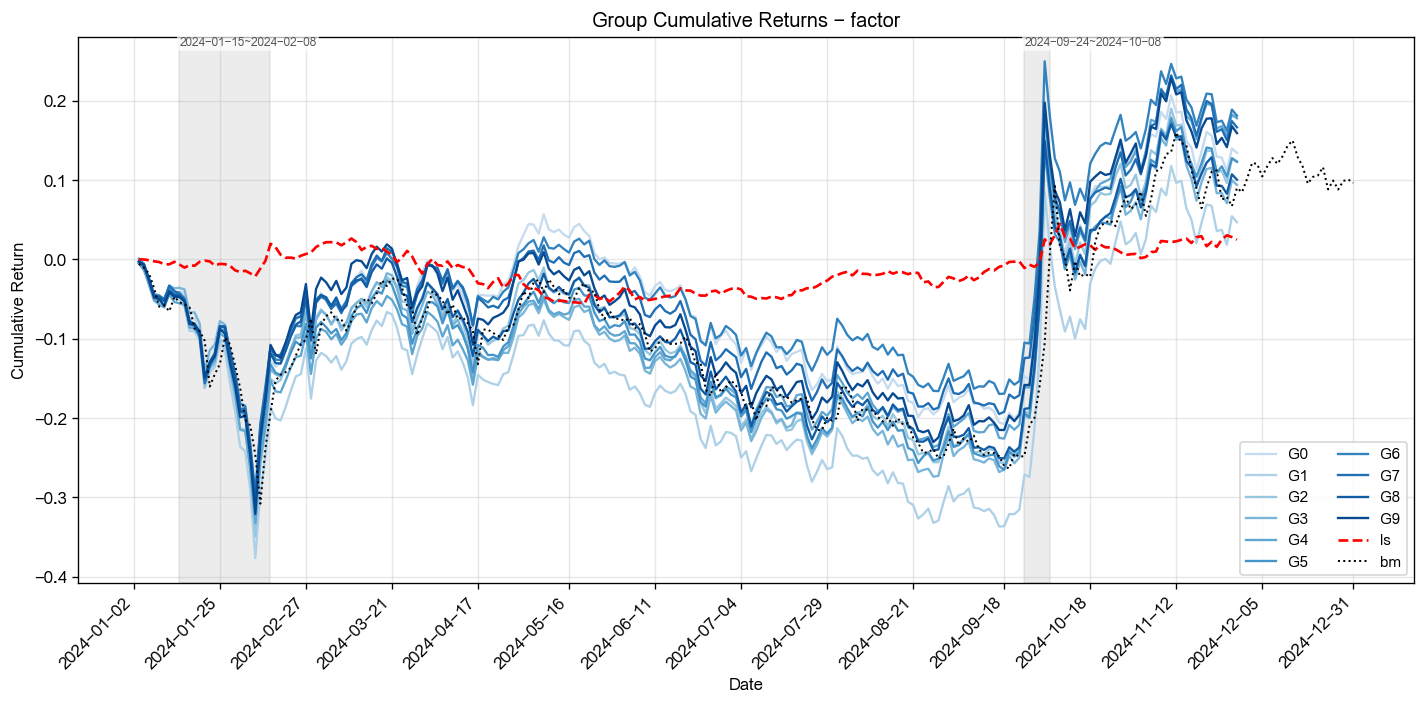
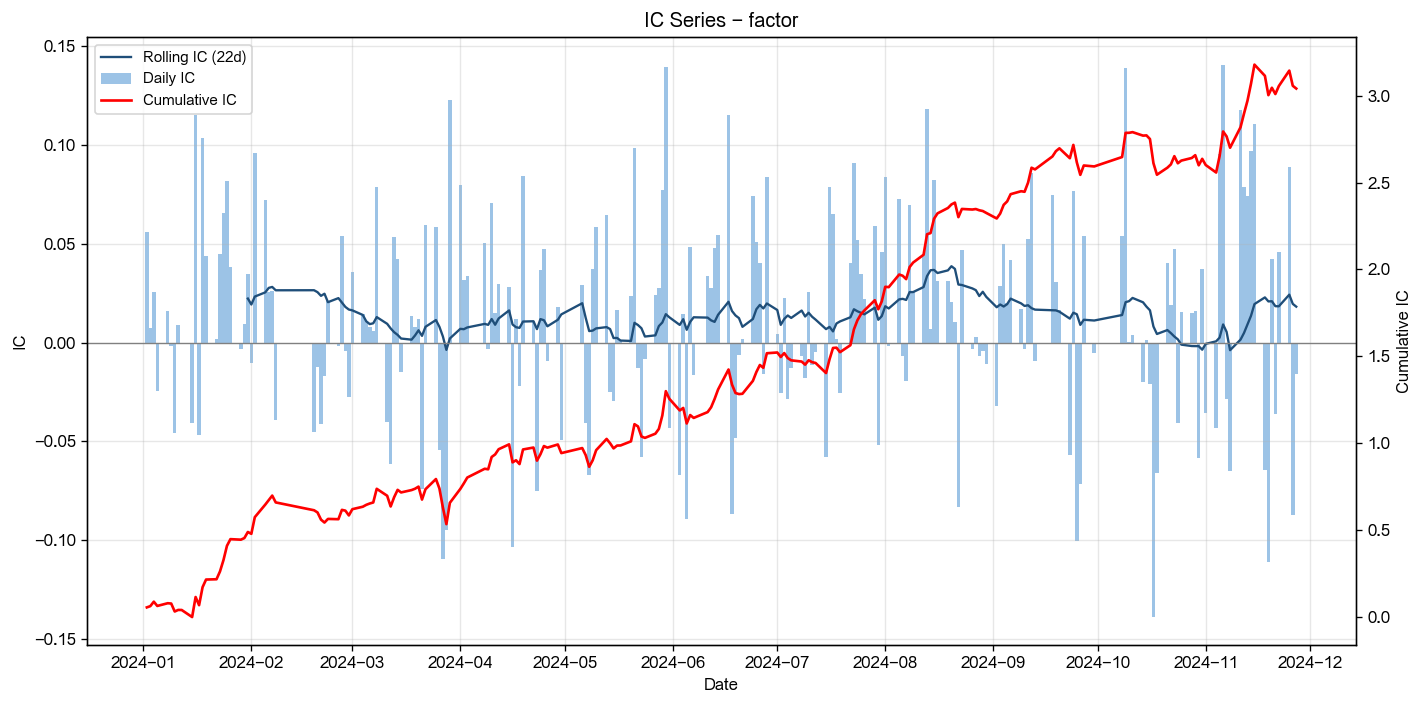
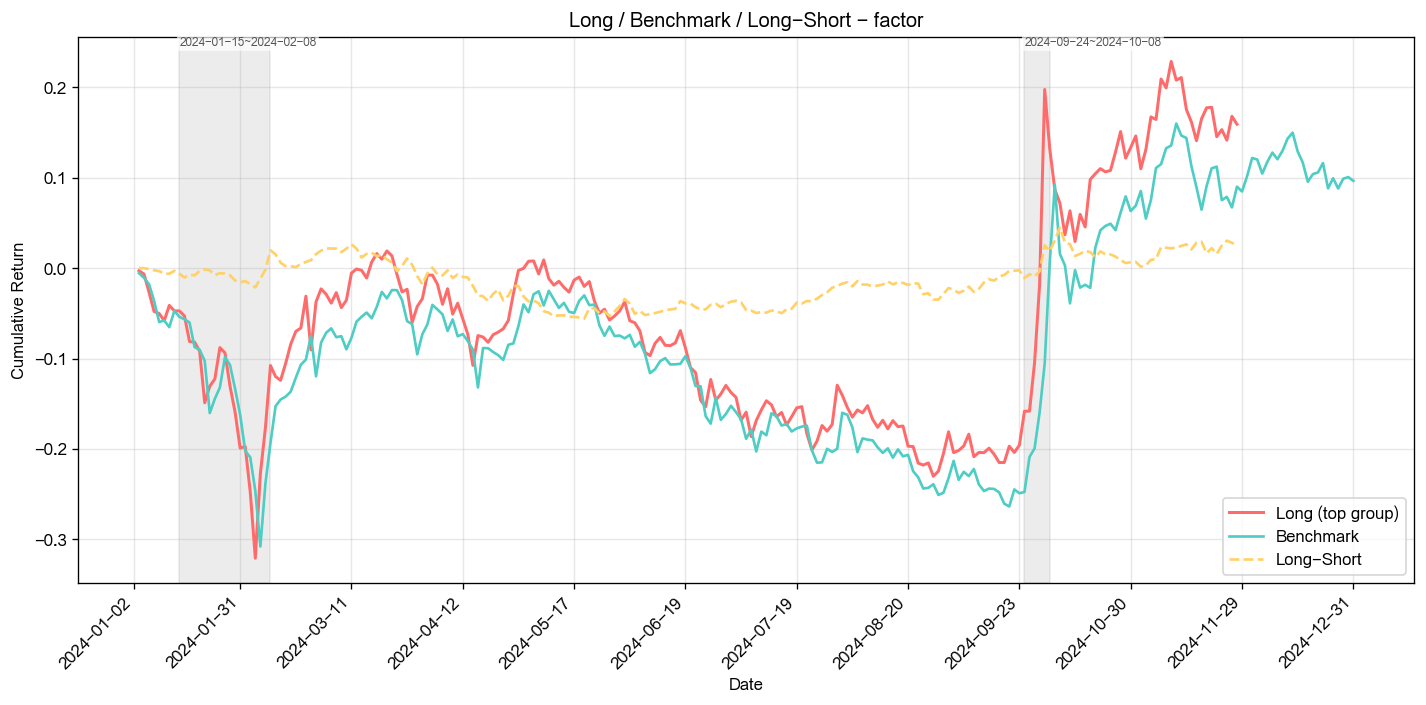
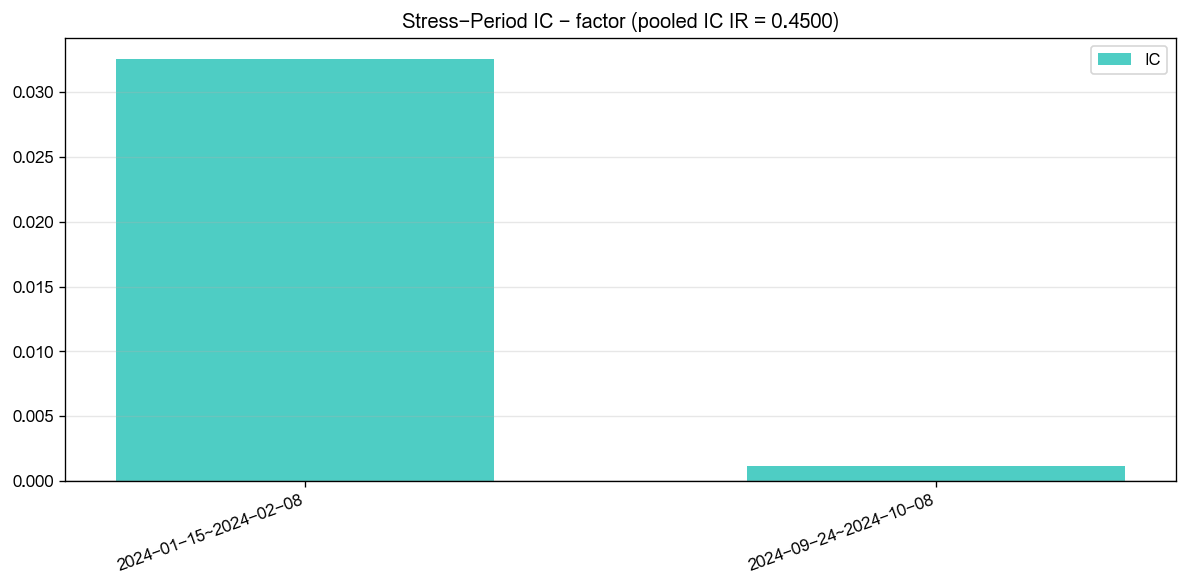
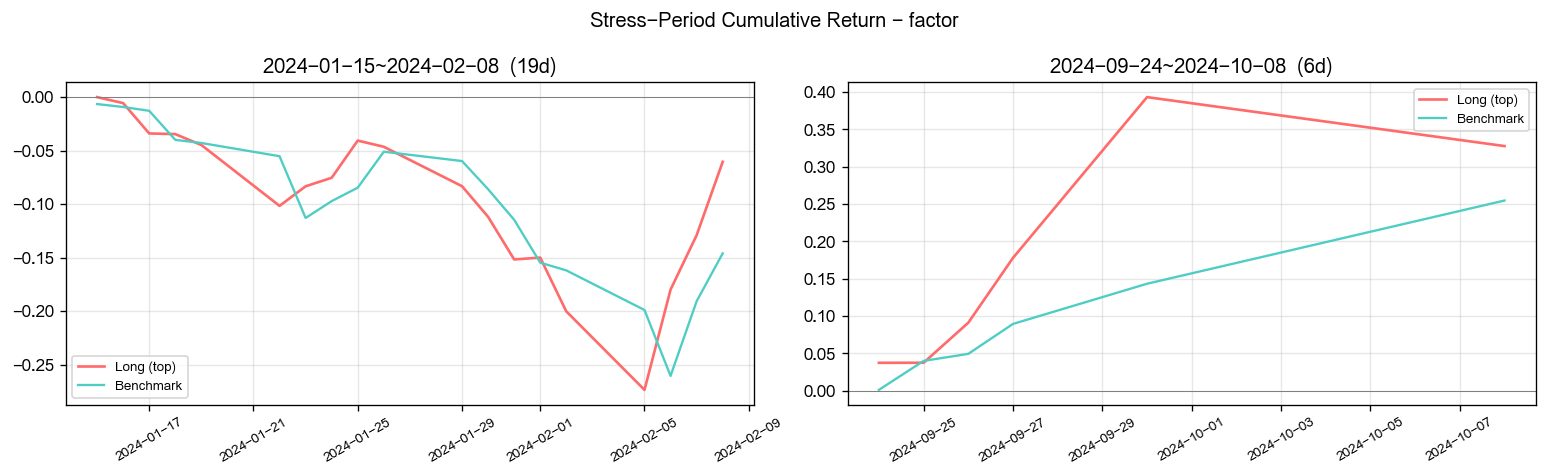

[2026-08-05 21:44:06] [info     ] ========== 因子池回归 ==========
[2026-08-05 21:44:06] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-05 21:44:07] [info     ] 获取收益率数据, 耗时: 0.7875 秒
[2026-08-05 21:44:07] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.5048 秒
[2026-08-05 21:44:07] [info     ] 统计 回归结果, 耗时: 0.095 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.8354,0.0443,0.0242,1.0000
2,amount,1.6977,0.0186,0.0109,0.9000
3,netflow_amount_rate_main,1.5350,0.0099,0.0065,1.0000
4,netflow_amount_main,1.5214,0.0253,0.0166,1.0000
5,gross_profit_rate_ttm,1.5112,0.0070,0.0046,1.0000
6,net_profit_rate_ttm,1.4386,0.0040,0.0028,0.8000
7,bias_20,1.4220,0.0292,0.0205,0.9000
8,pb,1.4099,0.0096,0.0068,1.0000
9,cci_14,1.3617,0.0337,0.0247,1.0000
10,ps_ttm,1.3500,0.0038,0.0028,0.9000

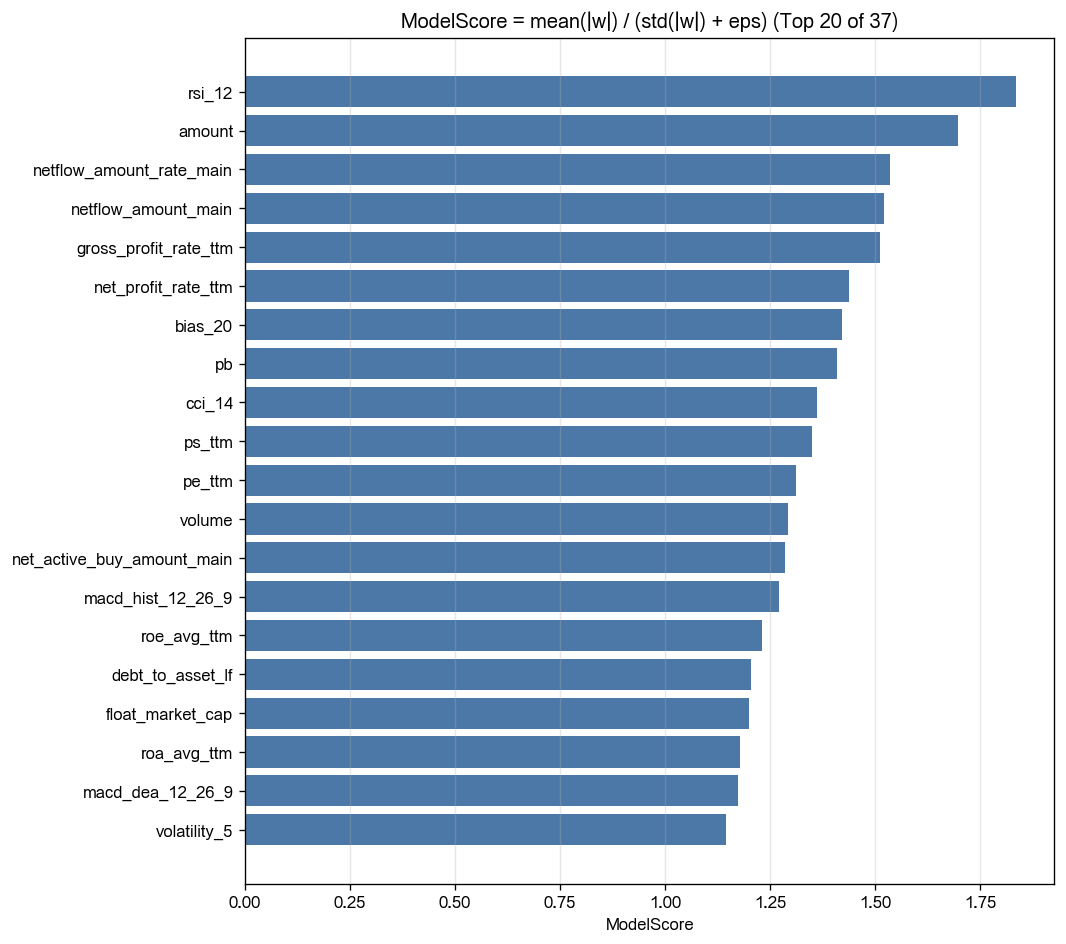
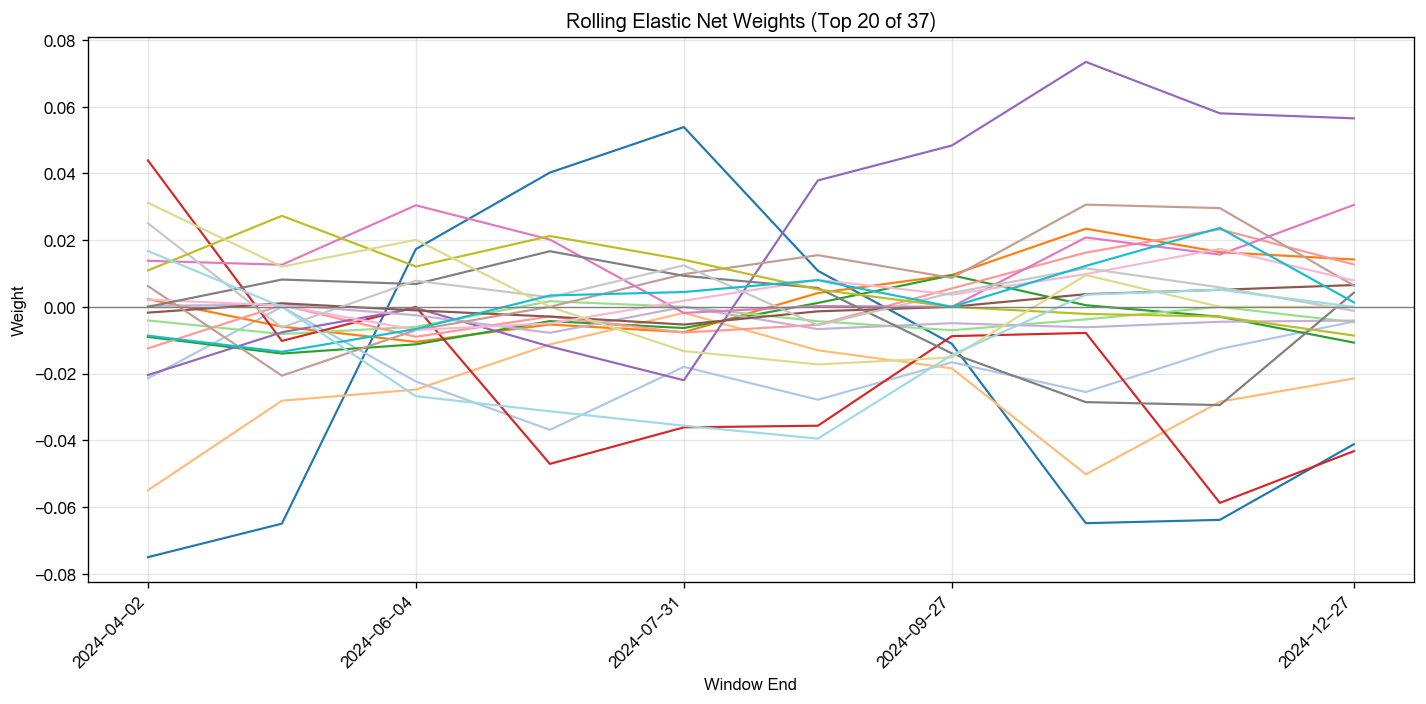
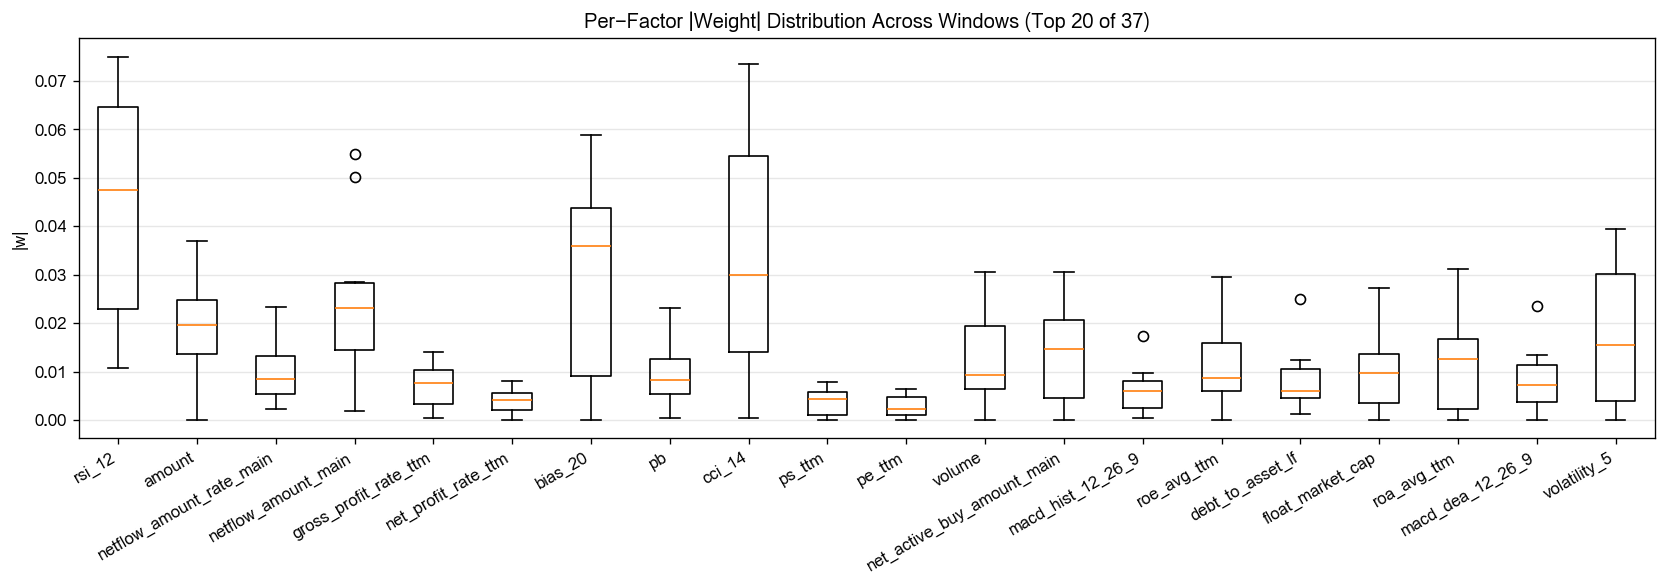
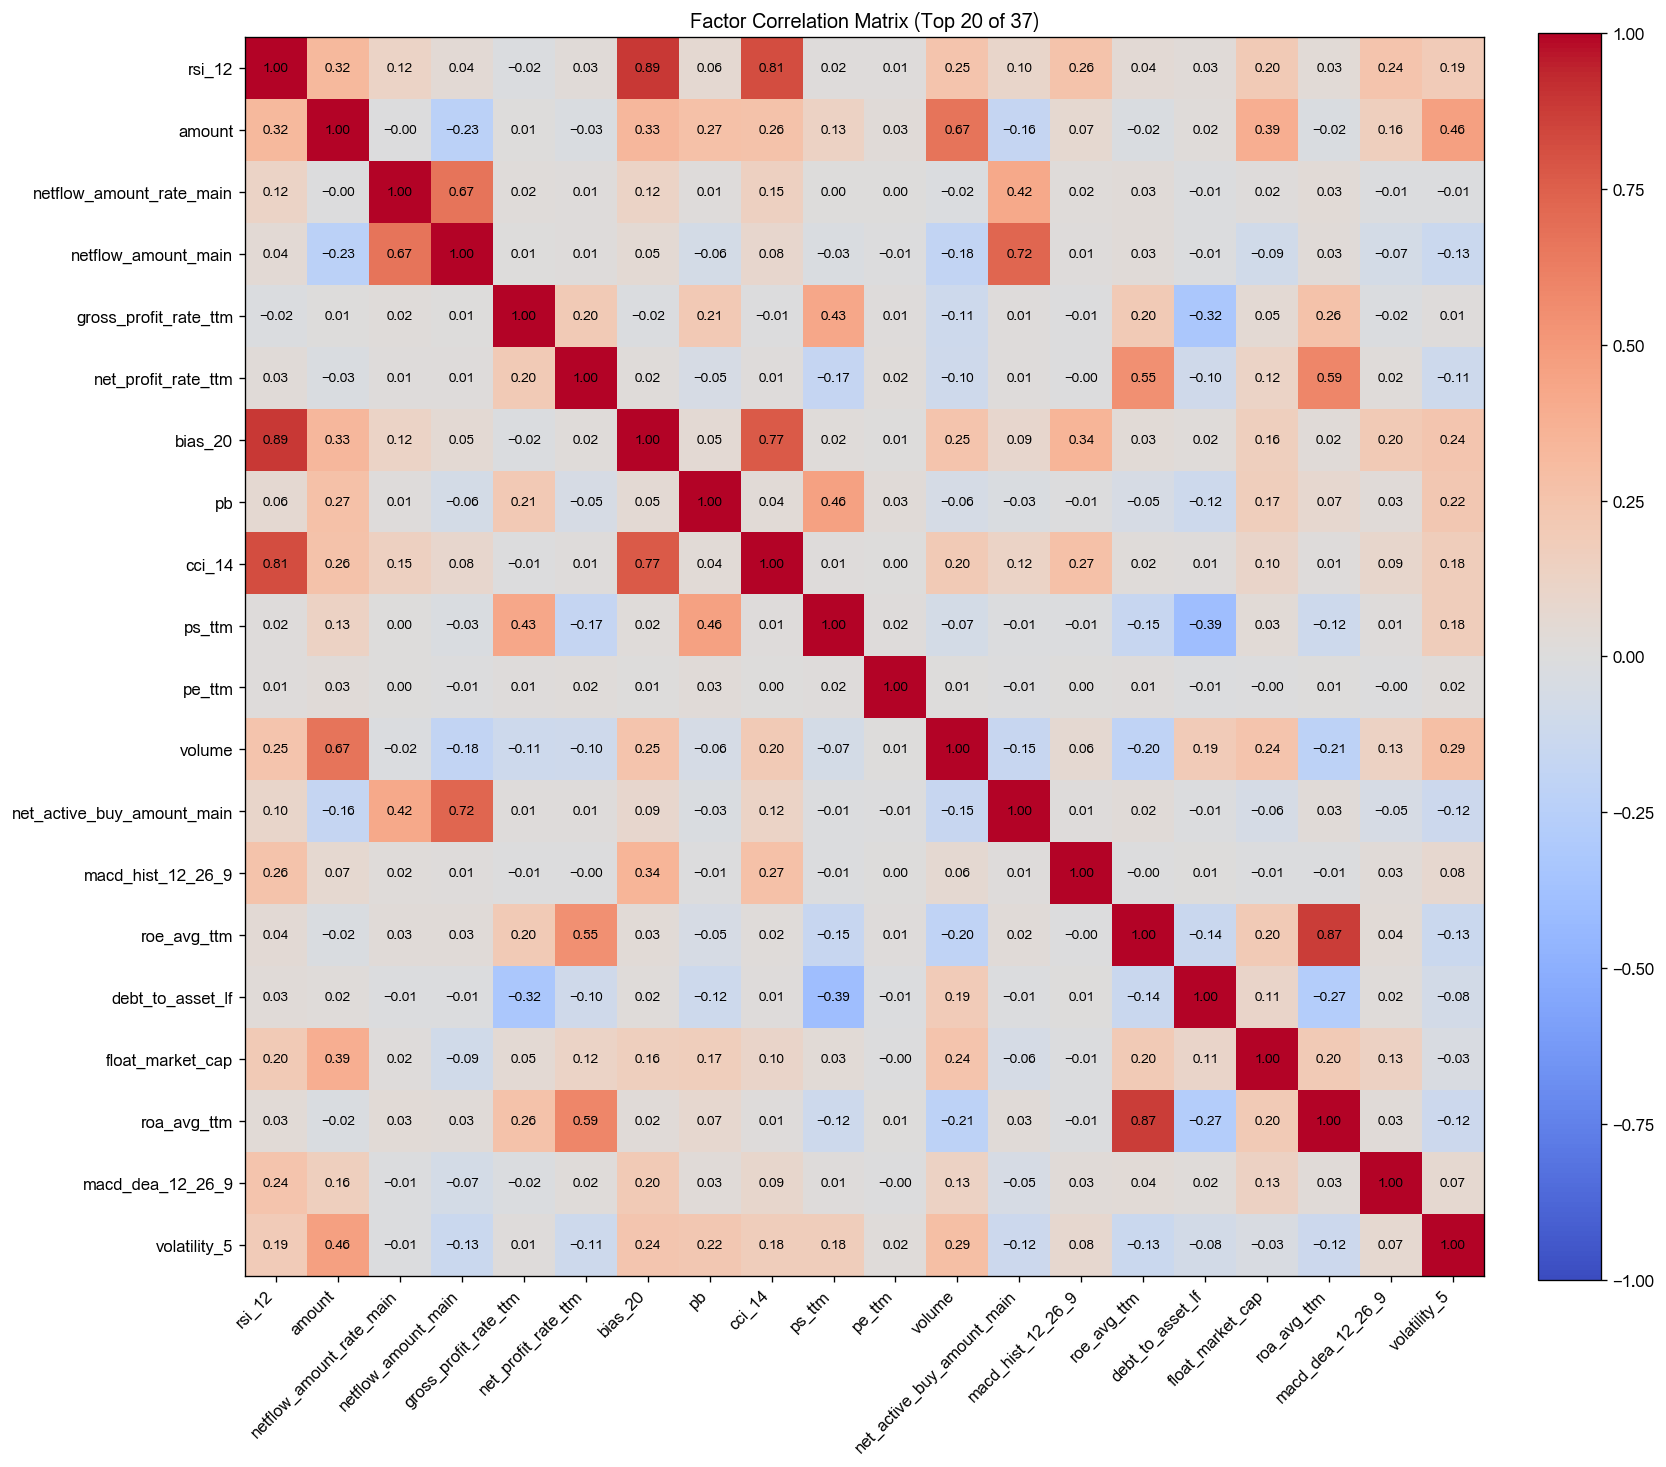

[2026-08-05 21:44:09] [warning  ] 返回的Outputs实例(size=35211469) 大于 64K, 将不会被缓存
[2026-08-05 21:44:09] [info     ] bigalpha_eval.v4 运行完成 [38.115s].


In [1]:
def main(datasources, start_date, end_date):
    """
    vol20d — 低波动异象因子

    公式: 过去20个交易日的日收益率标准差
    逻辑: A股低波动异象——波动越小的股票，未来收益越高
    方向: 因子值越大 = 波动越低 = 未来收益越高

    参数:
        datasources (dict): 数据源映射, 逻辑名 "bar1m" -> 物理表名
        start_date / end_date (str): 评估区间
    返回:
        pd.DataFrame: 三列 ['date', 'instrument', 'factor']
    """
    import pandas as pd
    import numpy as np
    import dai

    bar1m_table = datasources["bar1m"]

    LOOKBACK_DAYS = 365
    query_start = pd.to_datetime(start_date) - pd.Timedelta(days=LOOKBACK_DAYS)

    sql = f"""
    SELECT
        date::DATE::DATETIME AS date,
        instrument,
        LAST(close) AS close
    FROM {bar1m_table}
    GROUP BY date::DATE, instrument
    """
    daily = dai.query(sql, filters={'date': [query_start, end_date]}).df()
    daily['date'] = pd.to_datetime(daily['date'])

    close_p = daily.pivot(index='date', columns='instrument', values='close').sort_index()

    ret = close_p.pct_change()
    vol = ret.rolling(20, min_periods=10).std()

    factor_wide = (-vol).rank(axis=1, pct=True)

    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    mask = (factor_wide.index >= sd) & (factor_wide.index <= ed)
    factor_wide = factor_wide[mask]

    result = factor_wide.stack().reset_index()
    result.columns = ['date', 'instrument', 'factor']

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    stk_pool['date'] = pd.to_datetime(stk_pool['date'])

    result = pd.merge(stk_pool, result, how='left', on=['date', 'instrument'])
    result = result.sort_values(['instrument', 'date'])
    result['factor'] = result.groupby('instrument')['factor'].ffill()
    result = result.dropna(subset=['factor'])
    result = result[result['factor'].notna() & ~np.isinf(result['factor'])]
    return result[['date', 'instrument', 'factor']]


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算因子 vol20d，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
